
# Physical reconstruction from real VLF data: comparison of three background-separation families

This notebook produces the real-data counterpart of the synthetic *true vs reconstructed* figure. It does **not** rerun any inversion or VLF forward propagation. Instead, it reads the final **best solutions from the second perturbation runs** and the corresponding reconstructed physical backgrounds for the three separation families:

- **ASLS** background;
- **Whittaker** background;
- **Polynomial** background with respect to time.

The upper two rows compare the inferred physical parameterizations $\delta N_{e,z}(z)$, $\delta N_{e,t}(t)$, $h'(\chi)$, and $\beta(\chi)$ for the three families. The lower panel shows $\log_{10}(N_e)$ at Punta Lobos using only the **Whittaker** background and perturbation reconstruction. The electron-density field is masked above the physically calculated receiver reflection-height curve.

The source files are kept explicit and audited so that no first-run result, seed, or unrelated background is mixed into the figure.


In [1]:

# ============================================================
# 1. Packages and project functions
# ============================================================
using HDF5
using Dates
using TimeZones
using AstroLib
using Polynomials
using Interpolations
using LongwaveModePropagator
using CairoMakie
using LaTeXStrings
using DataFrames
using Printf
using Statistics

CairoMakie.activate!()

PROJECT_ROOT_LOCAL = isdefined(Main, :PROJECT_ROOT) ? PROJECT_ROOT : pwd()
preamble_path = joinpath(PROJECT_ROOT_LOCAL, "mytools", "preamble.jl")

if (!isdefined(Main, :waitprofile) || !isdefined(Main, :geolinspace)) && isfile(preamble_path)
    include(preamble_path)
end

@assert isdefined(Main, :waitprofile) "No encuentro `waitprofile`. Revisa PROJECT_ROOT o mytools/preamble.jl."
@assert isdefined(Main, :geolinspace) "No encuentro `geolinspace`. Revisa PROJECT_ROOT o mytools/preamble.jl."

FS_TICK   = 22
FS_LABEL  = 26
FS_TITLE  = 29
FS_LEGEND = 21
LW        = 4.0

METHOD_NAMES = ["ASLS", "Whittaker", "Polynomial"]
METHOD_COLORS = [:dodgerblue3, :darkgreen, :red3]
METHOD_LINESTYLES = [:dashdot, :dot, :solid]


[ Info: Loading CHAOS-7.11.mat


3-element Vector{Symbol}:
 :dashdot
 :dot
 :solid

In [2]:

# ============================================================
# 2. Canonical input files and output names
# ============================================================
function find_existing_file(
    name_or_path::AbstractString;
    env_name::AbstractString = "",
    extra_dirs::Vector{String} = String[],
)
    override = isempty(env_name) ? "" : strip(get(ENV, env_name, ""))
    requested = isempty(override) ? String(name_or_path) : override
    fname = basename(requested)

    roots = unique(vcat(
        [pwd(), PROJECT_ROOT_LOCAL, "/home/jp/basefolder_JP", "/mnt/data"],
        extra_dirs,
    ))

    candidates = String[requested, joinpath(pwd(), requested), joinpath(PROJECT_ROOT_LOCAL, requested)]
    for root in roots
        isempty(root) || push!(candidates, joinpath(root, fname))
    end

    for path in unique(candidates)
        isfile(path) && return abspath(path)
    end

    for root in roots
        isdir(root) || continue
        for (dir, _subdirs, files) in walkdir(root)
            if fname in files
                return abspath(joinpath(dir, fname))
            end
        end
    end

    error(
        "No encontré el archivo $(requested). " *
        (isempty(env_name) ? "" : "También puedes definir ENV[\"$(env_name)\"]."),
    )
end

OLD_BG_H5 = find_existing_file(
    "new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5";
    env_name = "OLD_BG_H5",
)

WHIT_BG_H5 = find_existing_file(
    "new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5";
    env_name = "WHIT_BG_H5",
)

POLY_BG_H5 = find_existing_file(
    "new-real-background-inversion_from_polyF3_simultaneous_restart_from_15706055_results_15742708.h5";
    env_name = "POLY_BG_H5",
)

OLD_SECOND_H5 = find_existing_file(
    "new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5";
    env_name = "OLD_SECOND_H5",
)

WHIT_SECOND_H5 = find_existing_file(
    "new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5";
    env_name = "WHIT_SECOND_H5",
)

POLY_SECOND_H5 = find_existing_file(
    "new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5";
    env_name = "POLY_SECOND_H5",
)

BG_PATHS = [OLD_BG_H5, WHIT_BG_H5, POLY_BG_H5]
PERT_PATHS = [OLD_SECOND_H5, WHIT_SECOND_H5, POLY_SECOND_H5]

OUTDIR = joinpath(pwd(), "real_3families_physical_reconstruction_figure")
mkpath(OUTDIR)

output_pdf = joinpath(OUTDIR, "real-d-region-3families-whittaker-heatmap.pdf")
output_png = joinpath(OUTDIR, "real-d-region-3families-whittaker-heatmap.png")

input_paths = DataFrame(
    method = repeat(METHOD_NAMES, inner = 2),
    role = repeat(["background best", "perturbation best — second run"], 3),
    path = vec(permutedims(hcat(BG_PATHS, PERT_PATHS))),
)

display(input_paths)
println("Output directory: ", OUTDIR)


Row,method,role,path
,String,String,String
1,ASLS,background best,/home/jp/basefolder_JP/new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5
2,ASLS,perturbation best — second run,/home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5
3,Whittaker,background best,/home/jp/basefolder_JP/new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5
4,Whittaker,perturbation best — second run,/home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5
5,Polynomial,background best,/home/jp/basefolder_JP/new-real-background-inversion_from_polyF3_simultaneous_restart_from_15706055_results_15742708.h5
6,Polynomial,perturbation best — second run,/home/jp/basefolder_JP/new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5


Output directory: /home/jp/basefolder_JP/real_3families_physical_reconstruction_figure


In [3]:

# ============================================================
# 3. HDF5 readers and parameter loaders
# ============================================================
function h5exists(path::AbstractString, key::AbstractString)
    h5open(path, "r") do f
        return haskey(f, key)
    end
end

function readvec(path::AbstractString, key::AbstractString)
    h5open(path, "r") do f
        return Float64.(vec(read(f[key])))
    end
end

function clean_h5_string(x)
    if x === nothing || x === missing
        return ""
    elseif x isa AbstractString
        return replace(String(x), "\0" => "")
    elseif x isa AbstractArray{UInt8}
        return replace(String(vec(x)), "\0" => "")
    elseif x isa AbstractArray && length(x) == 1
        return clean_h5_string(first(x))
    else
        return replace(string(x), "\0" => "")
    end
end

function read_attr_raw(path::AbstractString, key::AbstractString; default = nothing)
    h5open(path, "r") do f
        attrs = HDF5.attributes(f)
        return haskey(attrs, key) ? read(attrs[key]) : default
    end
end

attr_string(path::AbstractString, key::AbstractString; default = "") =
    clean_h5_string(read_attr_raw(path, key; default = default))

function attr_float(path::AbstractString, key::AbstractString; default = NaN)
    value = read_attr_raw(path, key; default = default)
    value isa AbstractArray && length(value) == 1 && (value = first(value))

    try
        return Float64(value)
    catch
        try
            return parse(Float64, clean_h5_string(value))
        catch
            return default
        end
    end
end

function first_existing_vector(
    path::AbstractString,
    keys::Vector{String};
    required::Bool = true,
)
    for key in keys
        if h5exists(path, key)
            return readvec(path, key), key
        end
    end

    required && error(
        "No encontré ninguna de estas llaves en $(basename(path)):\n" * join(keys, "\n"),
    )
    return nothing, ""
end

function load_background_parameters(path::AbstractString, label::AbstractString)
    h, h_key = first_existing_vector(
        path,
        [
            "reconstruction/h_coeffs",
            "reconstruction/hprime_coeffs",
            "best/h_coeffs",
            "h_coeffs",
        ];
        required = false,
    )

    beta, beta_key = first_existing_vector(
        path,
        [
            "reconstruction/beta_coeffs",
            "best/beta_coeffs",
            "beta_coeffs",
        ];
        required = false,
    )

    combined_key = ""
    if h === nothing || beta === nothing
        params, combined_key = first_existing_vector(
            path,
            [
                "reconstruction/params",
                "reconstruction/reco_params",
                "reconstruction/best_params",
                "reco_params",
                "best_params",
            ],
        )
        length(params) == 15 || error(
            "El vector combinado del background $(label) debe tener 15 parámetros; tiene $(length(params)).",
        )
        h = params[1:9]
        beta = params[10:15]
        h_key = combined_key * "[1:9]"
        beta_key = combined_key * "[10:15]"
    end

    length(h) == 9 || error("$(label): se esperaban 9 coeficientes para h′.")
    length(beta) == 6 || error("$(label): se esperaban 6 coeficientes para β.")
    all(isfinite, vcat(h, beta)) || error("$(label): hay coeficientes no finitos.")

    return (
        label = label,
        path = path,
        h_coeffs = Float64.(h),
        beta_coeffs = Float64.(beta),
        h_key = h_key,
        beta_key = beta_key,
    )
end

function load_perturbation_parameters(path::AbstractString, label::AbstractString)
    params, params_key = first_existing_vector(
        path,
        [
            "reconstruction/full_params",
            "reconstruction/params",
            "reconstruction/reco_params",
            "reco_params",
            "best_params",
        ],
    )

    t_pk_fixed_s = attr_float(path, "t_pk_fixed_s"; default = NaN)
    if !isfinite(t_pk_fixed_s) && h5exists(path, "fixed/t_pk_s")
        t_pk_fixed_s = first(readvec(path, "fixed/t_pk_s"))
    end

    if length(params) == 7
        amp, t_pk_from_vector, tau_u_s, tau_d_s, eps_s, z0_km, hz_km = params
        if isfinite(t_pk_fixed_s)
            isapprox(t_pk_from_vector, t_pk_fixed_s; atol = 1e-8, rtol = 0.0) || error(
                "$(label): t_pk del vector no coincide con el t_pk fijo del archivo.",
            )
        else
            t_pk_fixed_s = t_pk_from_vector
        end
    elseif length(params) == 6
        amp, tau_u_s, tau_d_s, eps_s, z0_km, hz_km = params
        isfinite(t_pk_fixed_s) || error(
            "$(label): el vector tiene 6 parámetros, pero no pude leer t_pk_fixed_s.",
        )
    else
        error(
            "$(label): esperaba 6 parámetros libres o 7 parámetros completos; encontré $(length(params)).",
        )
    end

    values = [amp, t_pk_fixed_s, tau_u_s, tau_d_s, eps_s, z0_km, hz_km]
    all(isfinite, values) || error("$(label): hay parámetros de perturbación no finitos.")
    minimum([amp, tau_u_s, tau_d_s, eps_s, hz_km]) > 0.0 || error(
        "$(label): hay escalas físicas no positivas.",
    )

    return (
        label = label,
        path = path,
        params_key = params_key,
        amp = amp,
        t_pk_s = t_pk_fixed_s,
        tau_u_s = tau_u_s,
        tau_d_s = tau_d_s,
        eps_s = eps_s,
        z0_km = z0_km,
        hz_km = hz_km,
        t_pk_fixed_utc = attr_string(path, "t_pk_fixed_utc"; default = ""),
        background_source_h5 = attr_string(path, "background_source_h5"; default = ""),
    )
end


load_perturbation_parameters (generic function with 1 method)

In [4]:

# ============================================================
# 4. Load and audit the three reconstruction families
# ============================================================
backgrounds = [
    load_background_parameters(BG_PATHS[i], METHOD_NAMES[i])
    for i in eachindex(METHOD_NAMES)
]

perturbations = [
    load_perturbation_parameters(PERT_PATHS[i], METHOD_NAMES[i])
    for i in eachindex(METHOD_NAMES)
]

for i in eachindex(METHOD_NAMES)
    stored_bg = strip(perturbations[i].background_source_h5)
    if !isempty(stored_bg)
        @assert basename(stored_bg) == basename(backgrounds[i].path) (
            "$(METHOD_NAMES[i]): el background registrado por la segunda inversión " *
            "no coincide con el archivo de background seleccionado."
        )
    end
end

@assert all(
    isapprox(p.t_pk_s, 1800.0; atol = 1e-8, rtol = 0.0)
    for p in perturbations
) "Al menos una familia no usa el t_pk fijo de 1800 s."

parameter_audit = DataFrame(
    method = METHOD_NAMES,
    background_file = basename.([x.path for x in backgrounds]),
    h_key = [x.h_key for x in backgrounds],
    beta_key = [x.beta_key for x in backgrounds],
    perturbation_file = basename.([x.path for x in perturbations]),
    perturbation_key = [x.params_key for x in perturbations],
    amp = [x.amp for x in perturbations],
    t_pk_s = [x.t_pk_s for x in perturbations],
    tau_u_s = [x.tau_u_s for x in perturbations],
    tau_d_s = [x.tau_d_s for x in perturbations],
    eps_s = [x.eps_s for x in perturbations],
    z0_km = [x.z0_km for x in perturbations],
    hz_km = [x.hz_km for x in perturbations],
)

display(parameter_audit)
println("Audit passed: only the three best second-run perturbation solutions are used.")


Row,method,background_file,h_key,beta_key,perturbation_file,perturbation_key,amp,t_pk_s,tau_u_s,tau_d_s,eps_s,z0_km,hz_km
,String,String,String,String,String,String,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,ASLS,new-real-background-inversion-bbo_from_old_asls_restart_results_13341497.h5,reconstruction/h_coeffs,reconstruction/beta_coeffs,new-perturbation-inversion_F3_nexp_oldASLS_BG13341497_FIXED_TPK_rel10_seed_from_15341092_results_15373069.h5,reconstruction/full_params,20.5159,1800.0,194.417,1293.86,761.786,76.1105,10.7799
2,Whittaker,new-real-background-inversion_from_sep_16_22_restart15_results_12976567.h5,reconstruction/h_coeffs,reconstruction/beta_coeffs,new-perturbation-inversion_F3_nexp_whittakerBG12976567_FIXED_TPK_restart_from15517278_rel10_z0wide20_results_15572093.h5,reconstruction/full_params,20.5537,1800.0,192.435,1322.16,818.49,74.2477,9.9598
3,Polynomial,new-real-background-inversion_from_polyF3_simultaneous_restart_from_15706055_results_15742708.h5,reconstruction/h_coeffs,reconstruction/beta_coeffs,new-perturbation-inversion_F3_nexp_polyF3BG15742708_FIXED_TPK_restart_from_15824988_rel10_results_15868514.h5,reconstruction/full_params,20.4982,1800.0,189.363,1342.7,807.615,77.2944,10.4146


Audit passed: only the three best second-run perturbation solutions are used.


In [5]:

# ============================================================
# 5. Physical parameterizations
# ============================================================
@inline vertical_perturbation(z_km::Real, z0_km::Real, hz_km::Real) =
    exp(clamp((z_km - z0_km) / hz_km, -50.0, 50.0))

@inline function temporal_perturbation(
    dt_s::Real,
    amp::Real,
    t_pk_s::Real,
    tau_u_s::Real,
    tau_d_s::Real,
    eps_s::Real,
)
    width_s = tau_u_s + 0.5 * (tau_d_s - tau_u_s) *
        (1.0 + tanh((dt_s - t_pk_s) / eps_s))
    return amp * exp(-0.5 * ((dt_s - t_pk_s) / width_s)^2)
end

@inline function total_electron_density(
    z_m::Real,
    hprime_km::Real,
    beta_km_inv::Real,
    dt_s::Real,
    pert,
)
    ne_bg = waitprofile(z_m, hprime_km, beta_km_inv)
    vertical = vertical_perturbation(z_m / 1e3, pert.z0_km, pert.hz_km)
    temporal = temporal_perturbation(
        dt_s,
        pert.amp,
        pert.t_pk_s,
        pert.tau_u_s,
        pert.tau_d_s,
        pert.eps_s,
    )
    return ne_bg * (1.0 + vertical * temporal)
end

function chi_signed_astrolib(
    lat_deg::Real,
    lon_deg::Real,
    zdt::ZonedDateTime;
    height_m::Real = 0.0,
    units::Symbol = :deg,
)
    zdt_utc = astimezone(zdt, tz"UTC")
    jd = AstroLib.jdcnv(DateTime(zdt_utc))
    ra, dec = AstroLib.sunpos(jd)
    alt_deg, az_deg, _ha_deg = AstroLib.eq2hor(
        ra, dec, jd, lat_deg, lon_deg, height_m
    )

    sza_deg = 90.0 - alt_deg
    chi_deg = (0.0 <= az_deg < 180.0) ? -sza_deg : +sza_deg
    return units === :rad ? deg2rad(chi_deg) : chi_deg
end


chi_signed_astrolib (generic function with 1 method)

In [6]:

# ============================================================
# 6. Time, altitude, geometry, and χ grids
# ============================================================
start_dt = DateTime(2008, 3, 25, 18, 0, 0)
stop_dt = DateTime(2008, 3, 25, 22, 0, 0)
time_dt = collect(start_dt:Minute(1):stop_dt)
time_zdt = ZonedDateTime.(time_dt, tz"UTC")
time_unix = Dates.datetime2unix.(time_dt)

# The fixed t_pk=1800 s is defined relative to 18:30 UTC in the inversion.
time_origin = ZonedDateTime(2008, 3, 25, 18, 30, 0, tz"UTC")
time_origin_unix = Dates.datetime2unix(DateTime(time_origin))
dt_seconds = time_unix .- time_origin_unix

time_hours_utc = [
    Dates.hour(dt) + Dates.minute(dt) / 60 + Dates.second(dt) / 3600
    for dt in time_dt
]

xticks_hours = collect(18.0:0.5:22.0)
xtick_labels = Dates.format.(collect(start_dt:Minute(30):stop_dt), "HH:MM")

lats_path, lons_path, _dists_path = geolinspace("NAA", "PLO", 19, false)
lat_rx = last(lats_path)
lon_rx = last(lons_path)

chi_rx_deg = chi_signed_astrolib.(lat_rx, lon_rx, time_zdt)
chi_grid_deg = collect(range(minimum(chi_rx_deg), maximum(chi_rx_deg); length = 400))
chi_grid_rad = deg2rad.(chi_grid_deg)

z_grid_km = collect(60.0:0.10:80.0)
z_grid_m = z_grid_km .* 1e3

println("PLO coordinates: lat=$(lat_rx)°, lon=$(lon_rx)°")
println(
    "χ domain at PLO: ",
    round(minimum(chi_rx_deg), digits = 3),
    "° to ",
    round(maximum(chi_rx_deg), digits = 3),
    "°",
)


PLO coordinates: lat=-12.499999999322473°, lon=-76.79999999990258°
χ domain at PLO: 18.713° to 72.592°


In [7]:

# ============================================================
# 7. Evaluate the three physical reconstructions
# ============================================================
h_polynomials = [Polynomial(bg.h_coeffs) for bg in backgrounds]
beta_polynomials = [Polynomial(bg.beta_coeffs) for bg in backgrounds]

h_chi = [p.(chi_grid_rad) for p in h_polynomials]
beta_chi = [p.(chi_grid_rad) for p in beta_polynomials]

vertical_profiles = [
    vertical_perturbation.(z_grid_km, pert.z0_km, pert.hz_km)
    for pert in perturbations
]

temporal_profiles = [
    temporal_perturbation.(
        dt_seconds,
        pert.amp,
        pert.t_pk_s,
        pert.tau_u_s,
        pert.tau_d_s,
        pert.eps_s,
    )
    for pert in perturbations
]

for i in eachindex(METHOD_NAMES)
    @assert all(isfinite, h_chi[i]) "$(METHOD_NAMES[i]): h′(χ) contiene valores no finitos."
    @assert all(isfinite, beta_chi[i]) "$(METHOD_NAMES[i]): β(χ) contiene valores no finitos."
    @assert minimum(beta_chi[i]) > 0.0 "$(METHOD_NAMES[i]): β(χ) alcanza valores no físicos."
    @assert all(isfinite, vertical_profiles[i])
    @assert all(isfinite, temporal_profiles[i])
end

ranges_audit = DataFrame(
    method = METHOD_NAMES,
    hprime_min_km = [minimum(v) for v in h_chi],
    hprime_max_km = [maximum(v) for v in h_chi],
    beta_min_km_inv = [minimum(v) for v in beta_chi],
    beta_max_km_inv = [maximum(v) for v in beta_chi],
    temporal_peak = [maximum(v) for v in temporal_profiles],
)

display(ranges_audit)


Row,method,hprime_min_km,hprime_max_km,beta_min_km_inv,beta_max_km_inv,temporal_peak
,String,Float64,Float64,Float64,Float64,Float64
1,ASLS,71.2966,75.9239,0.325688,0.39079,20.5159
2,Whittaker,71.8936,75.5062,0.322389,0.368046,20.5537
3,Polynomial,71.1127,75.1448,0.326633,0.386318,20.4982


In [8]:

# ============================================================
# 8. Whittaker Ne(z,t) field at Punta Lobos
# ============================================================
WHIT_IDX = findfirst(==("Whittaker"), METHOD_NAMES)
@assert WHIT_IDX !== nothing

bg_whit = backgrounds[WHIT_IDX]
pert_whit = perturbations[WHIT_IDX]
p_h_whit = h_polynomials[WHIT_IDX]
p_beta_whit = beta_polynomials[WHIT_IDX]

Nt = length(time_zdt)
Nz = length(z_grid_km)
Ne_whit = Matrix{Float64}(undef, Nt, Nz)
hprime_whit_time = Vector{Float64}(undef, Nt)
beta_whit_time = Vector{Float64}(undef, Nt)

for k in 1:Nt
    chi_rad = deg2rad(chi_rx_deg[k])
    hprime_whit_time[k] = p_h_whit(chi_rad)
    beta_whit_time[k] = p_beta_whit(chi_rad)

    for j in 1:Nz
        Ne_whit[k, j] = total_electron_density(
            z_grid_m[j],
            hprime_whit_time[k],
            beta_whit_time[k],
            dt_seconds[k],
            pert_whit,
        )
    end
end

@assert all(isfinite, Ne_whit)
@assert minimum(Ne_whit) > 0.0 "Ne_whit contiene valores no positivos."

Ne_floor = minimum(Ne_whit)
logNe_whit = log10.(max.(Ne_whit, Ne_floor))


241×201 Matrix{Float64}:
 7.37395  7.38318  7.39241  7.40165  …  9.19251  9.20174  9.21097  9.2202
 7.37348  7.38272  7.39195  7.40118     9.19243  9.20166  9.21089  9.22013
 7.373    7.38224  7.39148  7.40071     9.19234  9.20158  9.21081  9.22005
 7.37252  7.38175  7.39099  7.40023     9.19226  9.20149  9.21073  9.21997
 7.37202  7.38126  7.39049  7.39973     9.19217  9.20141  9.21064  9.21988
 7.37151  7.38075  7.38999  7.39923  …  9.19207  9.20131  9.21055  9.2198
 7.37099  7.38023  7.38947  7.39872     9.19197  9.20122  9.21046  9.2197
 7.37045  7.3797   7.38895  7.39819     9.19187  9.20112  9.21036  9.21961
 7.36991  7.37916  7.38841  7.39766     9.19176  9.20101  9.21026  9.21951
 7.36936  7.37861  7.38786  7.39711     9.19165  9.2009   9.21015  9.2194
 7.3688   7.37805  7.3873   7.39656  …  9.19154  9.20079  9.21004  9.21929
 7.36823  7.37748  7.38673  7.39599     9.19142  9.20067  9.20993  9.21918
 7.36764  7.3769   7.38616  7.39541     9.19129  9.20055  9.20981  9.21906
 ⋮  


## Receiver reflection height

The lower-panel boundary is calculated from the reconstructed Whittaker electron-density profile at each time. The routine solves the same LMP physical reflection condition used in the previous reconstruction plots through `waitsparameter`; it does **not** replace the reflection height with $h'$.


In [12]:
# ============================================================
# 9. Physical reflection height at RX from the Whittaker field
# ============================================================

function reflectionheight_v2_rx(
    ne_prof::AbstractVector{<:Real},
    alt_m::AbstractVector{<:Real},
    tx_freq,
    bfield;
    tol::Real = 1e-2,
    maxiter::Int = 80,
)::Float64
    length(ne_prof) == length(alt_m) ||
        error("ne_prof y alt_m deben tener la misma longitud.")

    alt = Float64.(alt_m)
    ne = Float64.(ne_prof)

    all(isfinite, alt) || return NaN
    all(isfinite, ne) || return NaN
    minimum(ne) > 0.0 || return NaN

    issorted(alt) ||
        error("alt_m debe estar ordenado de manera creciente.")

    # Explicit qualification avoids ambiguity with
    # NormalHermiteSplines.interpolate.
    ne_itp = Interpolations.extrapolate(
        Interpolations.interpolate(
            (alt,),
            ne,
            Interpolations.Gridded(Interpolations.Linear()),
        ),
        Interpolations.Line(),
    )

    sp = Species(
        QE,
        ME,
        ne_itp,
        electroncollisionfrequency,
    )

    omega_required = tx_freq.ω

    f(h) = waitsparameter(
        h,
        tx_freq,
        bfield,
        sp,
    ) - omega_required

    # Canonical interval, leaving 100 m inside each edge
    # of the supplied vertical grid.
    a = alt[1] + 100.0
    b = alt[end] - 100.0

    a < b || error(
        "El dominio vertical debe abarcar más de 200 m para calcular " *
        "la altura de reflexión."
    )

    fa = f(a)
    fb = f(b)

    # If the full interval does not bracket the root, search for a
    # sign-changing subinterval without modifying the physical
    # reflection condition.
    if !isfinite(fa) || !isfinite(fb) || signbit(fa) == signbit(fb)
        probe = collect(range(a, b; length = 401))
        fprobe = f.(probe)

        bracket_idx = findfirst(
            i ->
                isfinite(fprobe[i]) &&
                isfinite(fprobe[i + 1]) &&
                signbit(fprobe[i]) != signbit(fprobe[i + 1]),
            1:(length(probe) - 1),
        )

        bracket_idx === nothing && return NaN

        a = probe[bracket_idx]
        b = probe[bracket_idx + 1]
        fa = fprobe[bracket_idx]
        fb = fprobe[bracket_idx + 1]
    end

    c = 0.5 * (a + b)

    for _ in 1:maxiter
        c = 0.5 * (a + b)
        fc = f(c)

        isfinite(fc) || return NaN

        if abs(fc) <= tol || abs(b - a) <= tol
            return c / 1e3
        end

        if signbit(fa) == signbit(fc)
            a = c
            fa = fc
        else
            b = c
            fb = fc
        end
    end

    return c / 1e3
end

# Use the project transmitter and magnetic field when they
# are already defined. The explicit fallbacks reproduce the
# canonical NAA 24-kHz reflection diagnostic.
tx_frequency_rx = if isdefined(Main, :tx2) &&
                     hasproperty(getfield(Main, :tx2), :frequency)

    getproperty(getfield(Main, :tx2), :frequency)
else
    Frequency(24.0e3)
end

bfield_rx = if isdefined(Main, :bfield) &&
               getfield(Main, :bfield) isa BField

    getfield(Main, :bfield)
else
    BField(50e-6, pi / 2, 0.0)
end

reflection_height_rx_whit_km = [
    reflectionheight_v2_rx(
        view(Ne_whit, k, :),
        z_grid_m,
        tx_frequency_rx,
        bfield_rx,
    )
    for k in 1:Nt
]

failed_reflection = findall(
    x -> !isfinite(x),
    reflection_height_rx_whit_km,
)

@assert isempty(failed_reflection) (
    "No se pudo calcular la altura de reflexión en " *
    "$(length(failed_reflection)) tiempos. Índices fallidos: " *
    "$(failed_reflection). Revisa el BField del proyecto y el " *
    "dominio vertical."
)

println(
    "Whittaker reflection-height range at RX: ",
    round(
        minimum(reflection_height_rx_whit_km),
        digits = 3,
    ),
    "–",
    round(
        maximum(reflection_height_rx_whit_km),
        digits = 3,
    ),
    " km",
)

Whittaker reflection-height range at RX: 64.717–73.93 km


In [13]:

# ============================================================
# 10. Mask the Whittaker field above the reflection-height curve
# ============================================================
logNe_whit_masked = copy(logNe_whit)

for k in eachindex(time_hours_utc)
    for j in eachindex(z_grid_km)
        if z_grid_km[j] > reflection_height_rx_whit_km[k]
            logNe_whit_masked[k, j] = NaN
        end
    end
end

finite_logNe_whit = filter(isfinite, vec(logNe_whit_masked))
@assert !isempty(finite_logNe_whit) "La máscara eliminó todos los valores del heatmap."

masked_colorrange = extrema(finite_logNe_whit)
t_pk_hour_utc = Dates.hour(start_dt) + 0.5 + pert_whit.t_pk_s / 3600.0
@assert isapprox(t_pk_hour_utc, 19.0; atol = 1e-8)


Saved: /home/jp/basefolder_JP/real_3families_physical_reconstruction_figure/real-d-region-3families-whittaker-heatmap.pdf
Saved: /home/jp/basefolder_JP/real_3families_physical_reconstruction_figure/real-d-region-3families-whittaker-heatmap.png


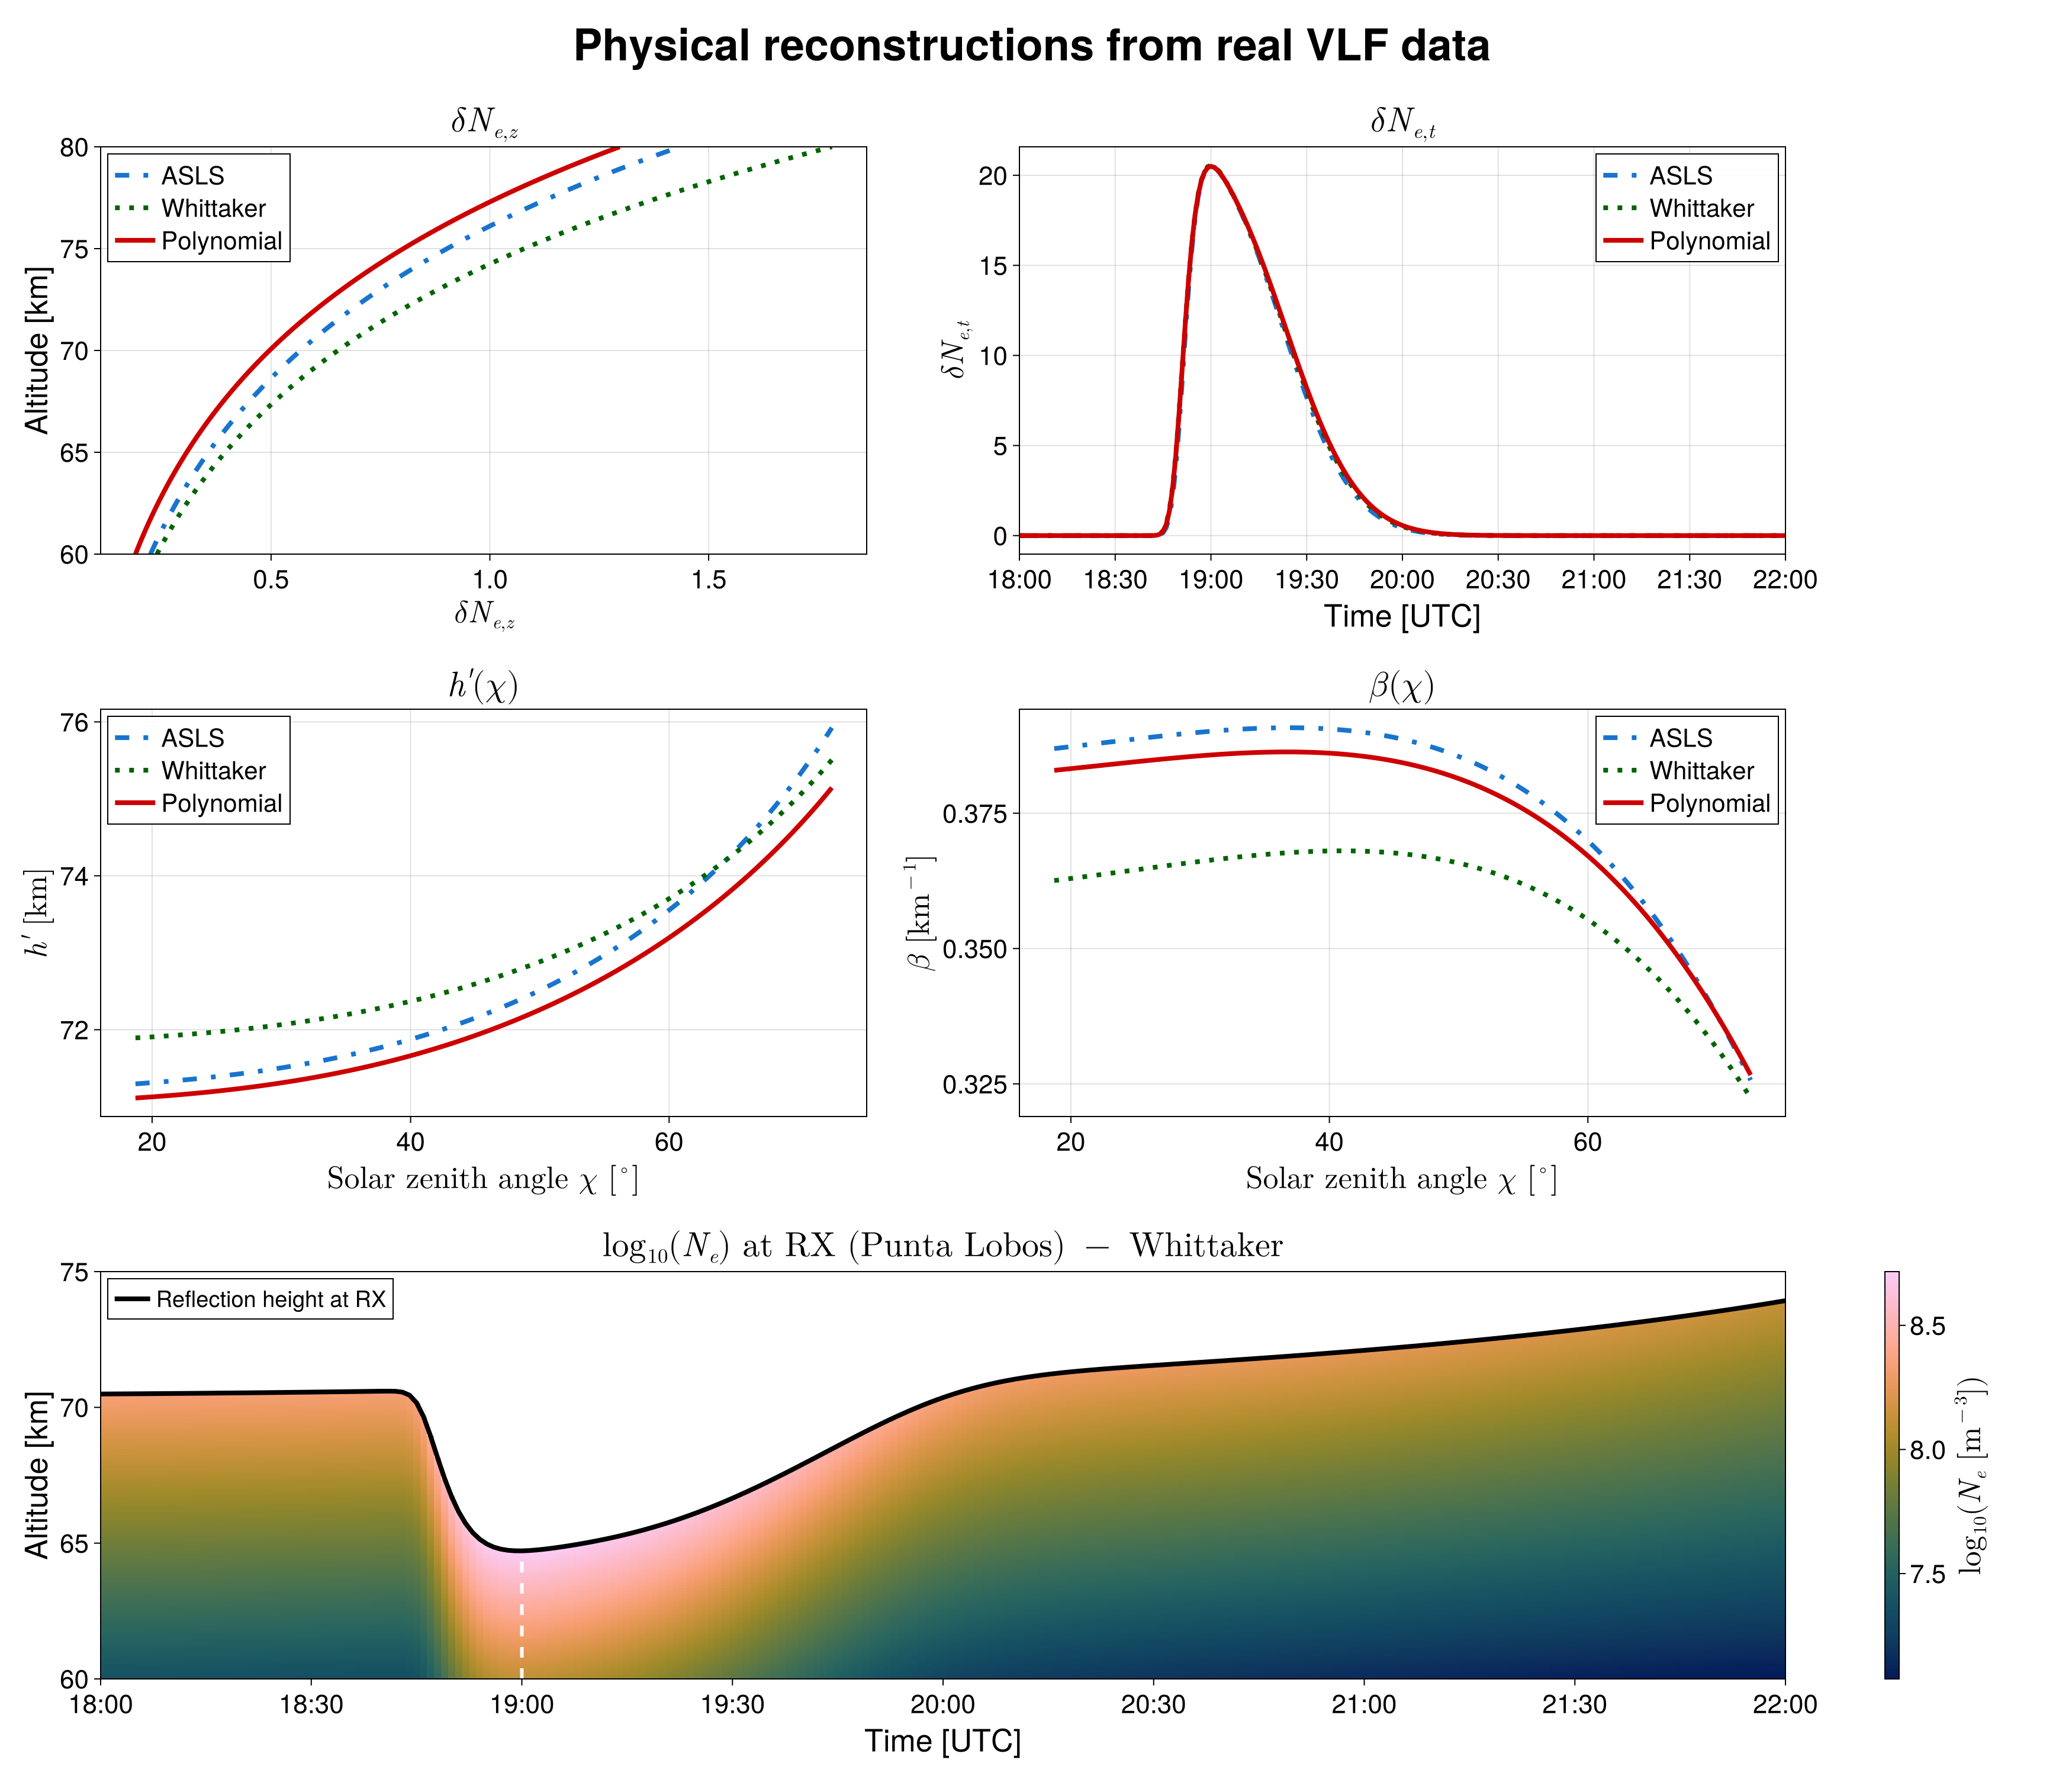

In [14]:

# ============================================================
# 11. Final paper figure
# ============================================================
fig = Figure(size = (1750, 1500), backgroundcolor = :white)

Label(
    fig[0, 1:3],
    "Physical reconstructions from real VLF data";
    fontsize = FS_TITLE + 8,
    font = :bold,
    halign = :center,
    tellwidth = false,
)

# ------------------------------------------------------------
# Row 1, column 1: vertical perturbation profiles
# ------------------------------------------------------------
ax_z = Axis(
    fig[1, 1],
    xlabel = L"\delta N_{e,z}",
    ylabel = "Altitude [km]",
    title = L"\delta N_{e,z}",
    limits = (nothing, (60.0, 80.0)),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
    xgridvisible = true,
    ygridvisible = true,
)

for i in eachindex(METHOD_NAMES)
    lines!(
        ax_z,
        vertical_profiles[i],
        z_grid_km;
        color = METHOD_COLORS[i],
        linestyle = METHOD_LINESTYLES[i],
        linewidth = LW,
        label = METHOD_NAMES[i],
    )
end

axislegend(
    ax_z;
    position = :lt,
    labelsize = FS_LEGEND,
    patchsize = (34, 18),
    framevisible = true,
    backgroundcolor = (:white, 0.90),
)

# ------------------------------------------------------------
# Row 1, column 2: temporal perturbation profiles
# ------------------------------------------------------------
ax_t = Axis(
    fig[1, 2],
    xlabel = "Time [UTC]",
    ylabel = L"\delta N_{e,t}",
    title = L"\delta N_{e,t}",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, nothing, nothing),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
    xgridvisible = true,
    ygridvisible = true,
)

for i in eachindex(METHOD_NAMES)
    lines!(
        ax_t,
        time_hours_utc,
        temporal_profiles[i];
        color = METHOD_COLORS[i],
        linestyle = METHOD_LINESTYLES[i],
        linewidth = LW,
        label = METHOD_NAMES[i],
    )
end

axislegend(
    ax_t;
    position = :rt,
    labelsize = FS_LEGEND,
    patchsize = (34, 18),
    framevisible = true,
    backgroundcolor = (:white, 0.90),
)

# ------------------------------------------------------------
# Row 2, column 1: h′(χ)
# ------------------------------------------------------------
ax_h = Axis(
    fig[2, 1],
    xlabel = L"\mathrm{Solar\ zenith\ angle}\ \chi\ [^\circ]",
    ylabel = L"h'\ [\mathrm{km}]",
    title = L"h'(\chi)",
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
    xgridvisible = true,
    ygridvisible = true,
)

for i in eachindex(METHOD_NAMES)
    lines!(
        ax_h,
        chi_grid_deg,
        h_chi[i];
        color = METHOD_COLORS[i],
        linestyle = METHOD_LINESTYLES[i],
        linewidth = LW,
        label = METHOD_NAMES[i],
    )
end

axislegend(
    ax_h;
    position = :lt,
    labelsize = FS_LEGEND,
    patchsize = (34, 18),
    framevisible = true,
    backgroundcolor = (:white, 0.90),
)

# ------------------------------------------------------------
# Row 2, column 2: β(χ)
# ------------------------------------------------------------
ax_beta = Axis(
    fig[2, 2],
    xlabel = L"\mathrm{Solar\ zenith\ angle}\ \chi\ [^\circ]",
    ylabel = L"\beta\ [\mathrm{km}^{-1}]",
    title = L"\beta(\chi)",
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
    xgridvisible = true,
    ygridvisible = true,
)

for i in eachindex(METHOD_NAMES)
    lines!(
        ax_beta,
        chi_grid_deg,
        beta_chi[i];
        color = METHOD_COLORS[i],
        linestyle = METHOD_LINESTYLES[i],
        linewidth = LW,
        label = METHOD_NAMES[i],
    )
end

axislegend(
    ax_beta;
    position = :rt,
    labelsize = FS_LEGEND,
    patchsize = (34, 18),
    framevisible = true,
    backgroundcolor = (:white, 0.90),
)

# ------------------------------------------------------------
# Row 3: Whittaker electron-density field at PLO
# ------------------------------------------------------------
ax_map = Axis(
    fig[3, 1:2],
    xlabel = "Time [UTC]",
    ylabel = "Altitude [km]",
    title = L"\log_{10}(N_e)\ \mathrm{at\ RX\ (Punta\ Lobos)}\ -\ \mathrm{Whittaker}",
    xticks = (xticks_hours, xtick_labels),
    limits = (18.0, 22.0, 60.0, 75.0),
    xlabelsize = FS_LABEL,
    ylabelsize = FS_LABEL,
    titlesize = FS_TITLE,
    xticklabelsize = FS_TICK,
    yticklabelsize = FS_TICK,
    xgridvisible = false,
    ygridvisible = false,
)

hm = heatmap!(
    ax_map,
    time_hours_utc,
    z_grid_km,
    logNe_whit_masked;
    colormap = :batlow,
    colorrange = masked_colorrange,
    nan_color = :white,
)

vlines!(
    ax_map,
    [t_pk_hour_utc];
    color = (:white, 0.95),
    linestyle = :dash,
    linewidth = 3,
)

lines!(
    ax_map,
    time_hours_utc,
    reflection_height_rx_whit_km;
    color = :black,
    linewidth = 4,
    label = "Reflection height at RX",
)

axislegend(
    ax_map;
    position = :lt,
    labelsize = FS_LEGEND - 2,
    patchsize = (30, 16),
    framevisible = true,
    backgroundcolor = (:white, 0.90),
)

Colorbar(
    fig[3, 3],
    hm;
    label = L"\log_{10}(N_e\ [\mathrm{m}^{-3}])",
    labelsize = FS_LABEL,
    ticklabelsize = FS_TICK,
)

colgap!(fig.layout, 30)
rowgap!(fig.layout, 28)
colsize!(fig.layout, 1, CairoMakie.Auto(1))
colsize!(fig.layout, 2, CairoMakie.Auto(1))
colsize!(fig.layout, 3, CairoMakie.Fixed(120))

save(output_pdf, fig)
save(output_png, fig; px_per_unit = 2)

println("Saved: ", output_pdf)
println("Saved: ", output_png)

fig



## Interpretation for the paper

The upper panels quantify how the inferred D-region background and flare perturbation depend on the method used to separate the measured VLF background. Unlike the synthetic validation figure, no curve is treated as a known truth. The lower panel is a physical realization based on the Whittaker family, selected here because its directly isolated flare perturbation is the clean reference used in the real-data analysis; this choice is not presented as a claim that Whittaker minimizes every background-fit metric.
